In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
smd= pd.read_csv("instagram_users_lifestyle.csv")
smd.shape

(1547896, 58)

In [2]:
smd.dtypes

user_id                             int64
app_name                           object
age                                 int64
gender                             object
country                            object
urban_rural                        object
income_level                       object
employment_status                  object
education_level                    object
relationship_status                object
has_children                       object
exercise_hours_per_week           float64
sleep_hours_per_night             float64
diet_quality                       object
smoking                            object
alcohol_frequency                  object
perceived_stress_score              int64
self_reported_happiness             int64
body_mass_index                   float64
blood_pressure_systolic             int64
blood_pressure_diastolic            int64
daily_steps_count                   int64
weekly_work_hours                 float64
hobbies_count                     

In [3]:
object_columns=smd.select_dtypes(include=['object'])
numerical_columns=smd.select_dtypes(include=['number'])

object_columns.shape ,numerical_columns.shape

((1547896, 20), (1547896, 38))

In [4]:
smd

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,1547892,Instagram,61,Female,United States,Suburban,High,Full-time employed,Master’s,Widowed,...,2025-01-14,15.8,Videos,Other,Friends only,Yes,Yes,4,Free,0.97
1547892,1547893,Instagram,42,Male,United States,Urban,Lower-middle,Full-time employed,Master’s,Divorced,...,2025-08-04,38.0,Photos,Art,Private,No,No,1,Premium,1.32
1547893,1547894,Instagram,32,Male,Canada,Urban,Low,Full-time employed,Master’s,Single,...,2025-04-10,31.8,Live,Other,Private,Yes,Yes,5,Free,1.01
1547894,1547895,Instagram,14,Female,Other,Urban,Low,Not employed,Bachelor’s,Single,...,2025-03-21,23.6,Live,Tech,Private,Yes,No,3,Free,1.11


In [5]:
smd['app_name'].unique()

array(['Instagram'], dtype=object)

In [6]:
smd['relationship_status'].unique()

array(['Single', 'Divorced', 'In a relationship', 'Married', 'Widowed'],
      dtype=object)

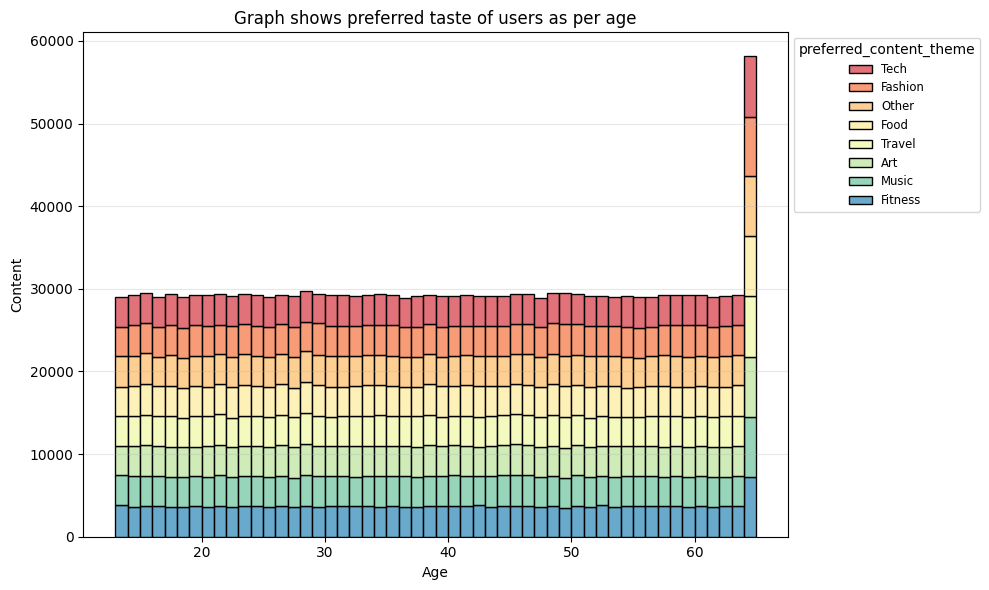

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10,6))

ax=sns.histplot(data=smd, x='age',hue='preferred_content_theme',multiple='stack',palette='Spectral',binwidth=1)
sns.move_legend(ax, "upper left", fontsize='small',bbox_to_anchor=(1,1))

plt.title("Graph shows preferred taste of users as per age")
plt.xlabel("Age")
plt.ylabel("Content")
plt.tight_layout()
plt.grid(axis='y',alpha=0.3)
plt.show()

In [8]:
print(smd['age'].value_counts().sort_index().tail(5))

age
61    28983
62    29188
63    29295
64    28983
65    29145
Name: count, dtype: int64


In [9]:
smd.groupby('age')['preferred_content_theme'].nunique()


age
13    8
14    8
15    8
16    8
17    8
18    8
19    8
20    8
21    8
22    8
23    8
24    8
25    8
26    8
27    8
28    8
29    8
30    8
31    8
32    8
33    8
34    8
35    8
36    8
37    8
38    8
39    8
40    8
41    8
42    8
43    8
44    8
45    8
46    8
47    8
48    8
49    8
50    8
51    8
52    8
53    8
54    8
55    8
56    8
57    8
58    8
59    8
60    8
61    8
62    8
63    8
64    8
65    8
Name: preferred_content_theme, dtype: int64

In [10]:
smd.groupby('urban_rural')['employment_status'].nunique()

urban_rural
Rural       7
Suburban    7
Urban       7
Name: employment_status, dtype: int64

In [11]:
smd['employment_status'].unique()

array(['Retired', 'Full-time employed', 'Student', 'Unemployed',
       'Freelancer', 'Not employed', 'Part-time'], dtype=object)

In [12]:
smd.groupby('urban_rural')['income_level'].nunique()

urban_rural
Rural       5
Suburban    5
Urban       5
Name: income_level, dtype: int64

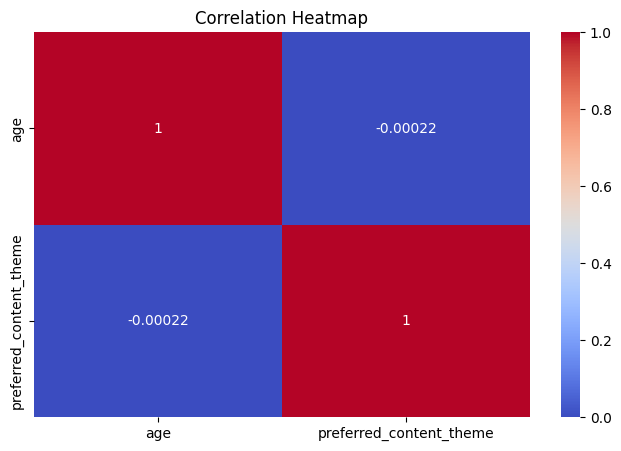

In [13]:
import category_encoders as ce
a=smd['preferred_content_theme']
pct=ce.OrdinalEncoder(cols=['preferred_content_theme'])
b=pct.fit_transform(smd)
e=b[['age','preferred_content_theme']].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(e, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [14]:
encode_label= ce.OrdinalEncoder(cols=object_columns)

smd_encoded=encode_label.fit_transform(smd)

smd_encoded

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,1,51,1,1,1,1,1,1,1,...,1,5.0,1,1,1,1,1,0,1,7.83
1,2,1,64,1,2,2,2,2,2,2,...,2,14.8,2,2,2,2,1,3,1,1.43
2,3,1,41,1,3,2,2,3,1,3,...,3,5.0,1,3,2,1,2,1,1,9.67
3,4,1,27,2,4,2,2,4,3,3,...,4,25.9,3,1,1,2,1,1,1,0.94
4,5,1,55,3,1,2,3,2,1,1,...,5,13.1,4,4,2,1,1,0,1,1.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547891,1547892,1,61,1,5,3,1,2,3,5,...,245,15.8,4,3,3,1,2,4,1,0.97
1547892,1547893,1,42,3,5,2,4,2,3,2,...,267,38.0,2,6,1,2,1,1,2,1.32
1547893,1547894,1,32,3,3,2,5,2,3,1,...,217,31.8,6,3,1,1,2,5,1,1.01
1547894,1547895,1,14,1,9,2,5,6,1,1,...,331,23.6,6,1,1,1,1,3,1,1.11


In [69]:
smd_encoded.isnull().sum()

user_id                           0
app_name                          0
age                               0
gender                            0
country                           0
urban_rural                       0
income_level                      0
employment_status                 0
education_level                   0
relationship_status               0
has_children                      0
exercise_hours_per_week           0
sleep_hours_per_night             0
diet_quality                      0
smoking                           0
alcohol_frequency                 0
perceived_stress_score            0
self_reported_happiness           0
body_mass_index                   0
blood_pressure_systolic           0
blood_pressure_diastolic          0
daily_steps_count                 0
weekly_work_hours                 0
hobbies_count                     0
social_events_per_month           0
books_read_per_year               0
volunteer_hours_per_month         0
travel_frequency_per_year   

In [15]:
smd.duplicated().sum()

np.int64(0)

In [16]:
smd_encoded.duplicated().sum()

np.int64(0)

In [17]:
z1=smd_encoded.drop(columns=['user_id','subscription_status'])
z2=smd_encoded['subscription_status']

from sklearn.feature_selection import SelectKBest,f_classif
from sklearn.preprocessing import StandardScaler

scaled=StandardScaler()

scaled_values=scaled.fit_transform(z1)

selector=SelectKBest(score_func=f_classif,k='all')
fit=selector.fit(scaled_values,z2)

feature_scores= pd.DataFrame({"Features":z1.columns,"feature_scores":fit.scores_}).sort_values(by='feature_scores',ascending=False)

print("best feature scores are", "\n", feature_scores)


best feature scores are 
                           Features  feature_scores
20               daily_steps_count        2.377777
43                 following_count        1.485897
13                         smoking        1.353737
53            biometric_login_used        1.346753
16         self_reported_happiness        1.157851
54           linked_accounts_count        1.080020
22                   hobbies_count        1.000088
26       travel_frequency_per_year        0.953397
44           uses_premium_features        0.921706
46           account_creation_year        0.854375
21               weekly_work_hours        0.816641
45      notification_response_rate        0.782656
19        blood_pressure_diastolic        0.756236
10         exercise_hours_per_week        0.721183
17                 body_mass_index        0.644825
37             ads_clicked_per_day        0.642156
48  average_session_length_minutes        0.638682
52         two_factor_auth_enabled        0.633867
18   

[[0.         6.66014151 6.69291351 6.72482912 6.90016829]
 [0.         5.55902885 6.10551941 6.11409395 6.25857813]
 [0.         6.18238167 6.47237489 6.57641149 6.60006314]
 ...
 [0.         6.24214353 6.41620769 6.62244797 6.71352203]
 [0.         6.64108331 7.18803399 7.3382566  7.38101716]
 [0.         6.62830397 7.33235966 7.63491123 7.68483628]] [[   0  506  470 1731    2]
 [   1  456  901 1507  124]
 [   2 1136 1340   12 1260]
 ...
 [1997 1895 1383 1703 1356]
 [1998  979 1833  509  749]
 [1999 1075 1486  249  234]]


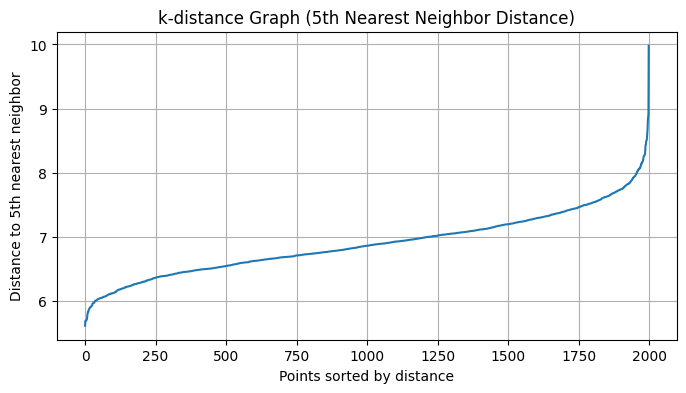

In [18]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

sample=scaled_values[0:2000,0:2000]
neigh = NearestNeighbors(n_neighbors=5,algorithm='kd_tree')
nbrs = neigh.fit(sample)
distances, indices = nbrs.kneighbors(sample)
print(distances,indices)

distances = np.sort(distances[:, -1])
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title("k-distance Graph (5th Nearest Neighbor Distance)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Distance to 5th nearest neighbor")
plt.grid(True)
plt.show()


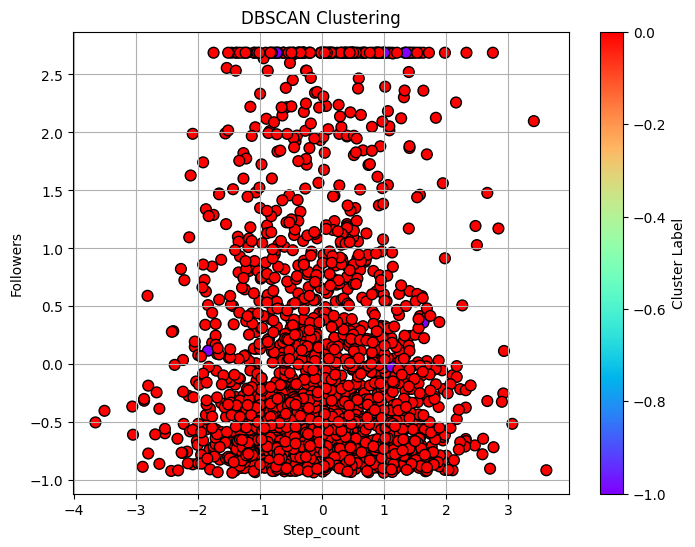

In [21]:
dbs=DBSCAN(eps=8,min_samples=5)
labels=dbs.fit_predict(sample)

plt.figure(figsize=(8, 6))
plt.scatter(sample[:,20],sample[:,43], c=labels, cmap='rainbow', s=60, edgecolor='k')
plt.xlabel('Step_count')
plt.ylabel('Followers')
plt.title('DBSCAN Clustering')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()

In [33]:
unique,counts=np.unique(labels,return_counts=True)
cluster_info=dict(zip(unique,counts))

for labels,counts in cluster_info.items():
    if labels==-1:
        print(f"Noise points: {counts}")
    else:
        print(f"Cluster {labels}: {counts} points")


    

Cluster 0: 1 points


In [60]:
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
z2_sample=z2[0:2000]

sample_train,sample_test,z2_sample_train,z2_sample_test=train_test_split(sample,z2_sample,test_size=0.3,stratify= z2_sample,random_state=0)

model_1=RandomForestClassifier(n_estimators=10,max_depth=None,min_samples_split=2,min_samples_leaf=1,max_features='sqrt',bootstrap=True,
class_weight=None,random_state=42)

model_2=LogisticRegression(penalty='l2')

model_3=DecisionTreeClassifier(criterion='gini',max_depth=3, min_samples_split=2,min_samples_leaf=1,max_features=None,class_weight=None,
random_state=42)

model_4=SVC(kernel='rbf',C=1.0,gamma='scale',degree=3)




In [61]:
models={"DecisonTree":model_3,"RandomForest":model_1,"Logistic":model_2,"SVM":model_4}

result=[]
for model_name, model in models.items():

    pipeline = Pipeline([
        ("classifier", model)
    ])

    pipeline.fit(sample_train, z2_sample_train)
    prediction = pipeline.predict(sample_test)

    acc = accuracy_score(z2_sample_test, prediction)

    result.append({
        "model": model_name,
        "accuracy": acc
    })

    print(f"\nModel: {model_name}")
    print("Accuracy:", acc)
    print("classification_report is", "\n", classification_report(z2_sample_test, prediction))


result_df = pd.DataFrame(result)
print("\nSorted Results:")
print(result_df.sort_values(by='accuracy', ascending=False))
    




Model: DecisonTree
Accuracy: 0.74
classification_report is 
               precision    recall  f1-score   support

           1       0.74      0.99      0.85       446
           2       0.00      0.00      0.00        96
           3       0.20      0.02      0.03        58

    accuracy                           0.74       600
   macro avg       0.31      0.34      0.29       600
weighted avg       0.57      0.74      0.64       600


Model: RandomForest
Accuracy: 0.7266666666666667
classification_report is 
               precision    recall  f1-score   support

           1       0.74      0.98      0.84       446
           2       0.09      0.01      0.02        96
           3       0.00      0.00      0.00        58

    accuracy                           0.73       600
   macro avg       0.28      0.33      0.29       600
weighted avg       0.57      0.73      0.63       600


Model: Logistic
Accuracy: 0.74
classification_report is 
               precision    recall  f1-sc

confusion matrix is 
 [[446  96  58]
 [  0   0   0]
 [  0   0   0]]


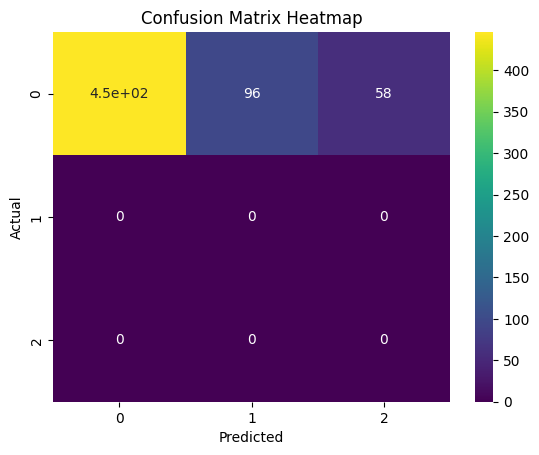

In [62]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(prediction,z2_sample_test)
print("confusion matrix is " "\n", cm)

sns.heatmap(cm,annot=True,cmap='viridis')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

